# 4

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
import numpy as np

X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_repeated=0,
                           random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=2)
model = LogisticRegression().fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]

In [2]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, proba)

def f_beta(prec, rec, beta):
    b2 = beta**2
    return (1 + b2) * (prec * rec) / (b2 * prec + rec + 1e-9)


In [3]:
def f_beta(prec, rec, beta):
    b2 = beta**2
    return (1 + b2) * (prec * rec) / (b2 * prec + rec + 1e-9)

f05 = f_beta(precision, recall, 0.5)
f2  = f_beta(precision, recall, 2.0)

ix05 = np.argmax(f05)
ix2  = np.argmax(f2)

In [5]:
print("beta=0.5 best threshold %.3f  precision %.3f  recall %.3f  F0.5 %.3f" %
      ( thresholds[ix05], precision[ix05], recall[ix05], f05[ix05] ))
print("beta=2   best threshold %.3f  precision %.3f  recall %.3f  F2   %.3f" %
      ( thresholds[ix2],  precision[ix2],  recall[ix2],  f2[ix2] ))


beta=0.5 best threshold 0.747  precision 0.901  recall 0.720  F0.5 0.857
beta=2   best threshold 0.234  precision 0.722  recall 0.958  F2   0.899


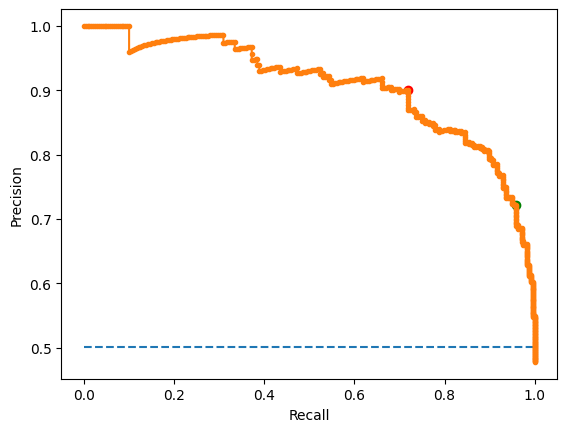

In [6]:
from matplotlib import pyplot as plt
plt.figure()
no_skill = y.mean()
plt.plot([0, 1], [no_skill, no_skill], '--', label='no skill')
plt.plot(recall, precision, marker='.', label='PR curve')
plt.scatter(recall[ix05], precision[ix05], color='red',
            label='opt β=0.5')
plt.scatter(recall[ix2], precision[ix2], color='green',
            label='opt β=2')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.show()


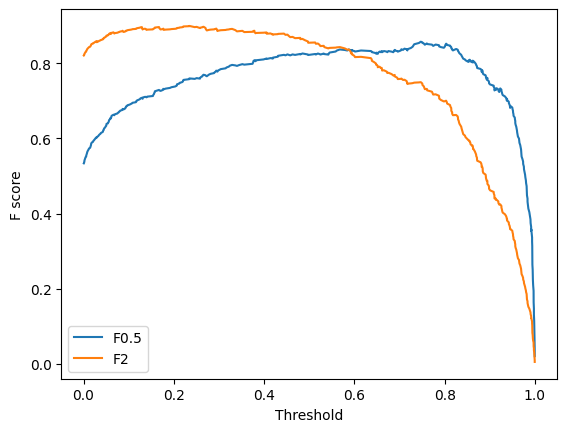

In [7]:
plt.figure()
plt.plot(thresholds, f05[:-1], label='F0.5')
plt.plot(thresholds, f2[:-1],  label='F2')
plt.xlabel('Threshold'); plt.ylabel('F score')
plt.legend()

In [9]:
from sklearn.metrics import classification_report
for name, ix in [('beta=0.5', ix05), ('veta=2', ix2)]:
    pred = (proba >= thresholds[ix]).astype(int)
    print(f"\n{name}")
    print(classification_report(y_test, pred))


beta=0.5
              precision    recall  f1-score   support

           0       0.78      0.93      0.85       261
           1       0.90      0.72      0.80       239

    accuracy                           0.83       500
   macro avg       0.84      0.82      0.82       500
weighted avg       0.84      0.83      0.83       500


veta=2
              precision    recall  f1-score   support

           0       0.95      0.66      0.78       261
           1       0.72      0.96      0.82       239

    accuracy                           0.80       500
   macro avg       0.83      0.81      0.80       500
weighted avg       0.84      0.80      0.80       500

